# Lab 5
---
### Name: Mohammed Feras Sawab

### ID: 2240009066
---

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
image = cv2.imread('../lab4/images/images.jpeg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

sigma=2
amount=1.5

image_float = image.astype(np.float32) / 255.0

# Apply Gaussian blur
blurred = cv2.GaussianBlur(image_float, (0, 0), sigmaX=sigma, sigmaY=sigma)

sharpened = np.clip(image_float + amount * (image_float - blurred), 0, 1)

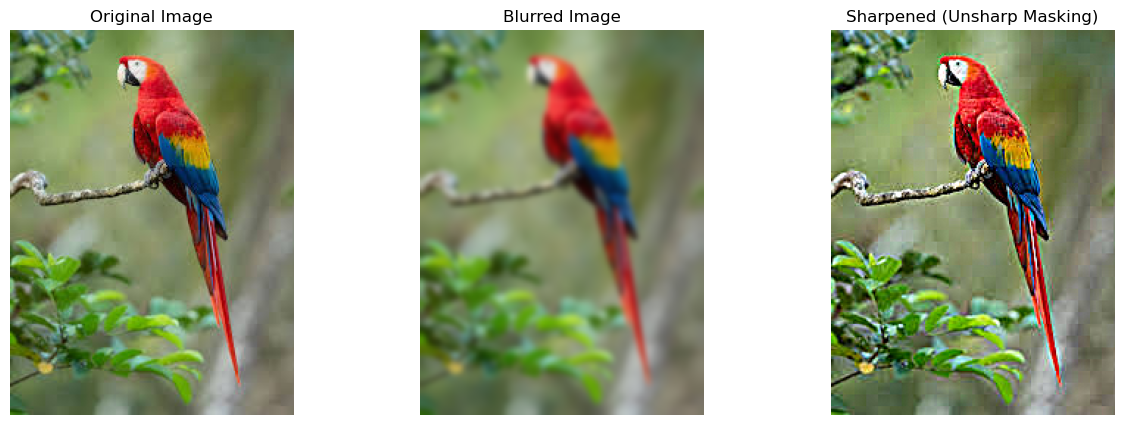

In [3]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(image)
ax[0].set_title("Original Image")
ax[0].axis("off")
ax[1].imshow(blurred)
ax[1].set_title("Blurred Image")
ax[1].axis("off")
ax[2].imshow(sharpened)
ax[2].set_title("Sharpened (Unsharp Masking)")
ax[2].axis("off")
plt.show()

Task#1: Convolve an image with a 7x7 box filter, and output the original and smoothed
image side by side

Task#2: Using an image of your choice, apply a 5x5 Gaussian filter to the image, then a
21x21 Gaussian filter, and show the three images side by side.

Task#3: Using an image of your choice, apply a 3x3 Laplacian filter to sharpen the image.
Follow the following steps:
1. Read the image
2. Convert image to float32
3. Use the cv2.Laplacian() function
4. Sharpen the image using: np.clip(image_float - laplacian, 0, 1)
5. Plot the original image, the resulting image after applying the Laplacian filter, and the
sharpened image

### Task 1: 7x7 box filter

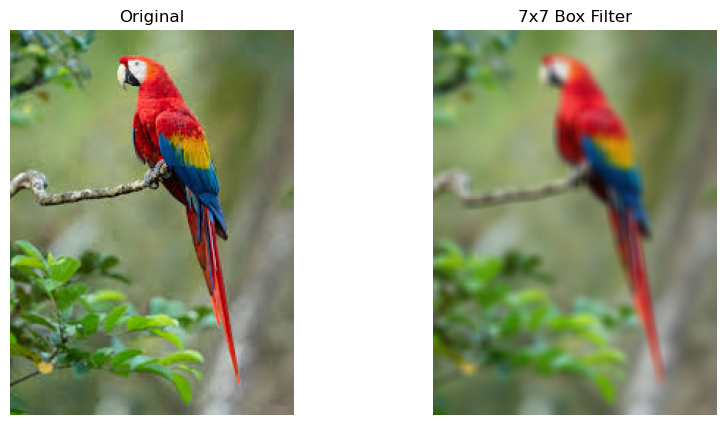

In [4]:
img = cv2.cvtColor(cv2.imread('images/images.jpeg'), cv2.COLOR_BGR2RGB)
kernel = np.ones((7, 7), np.float32) / 49
box = cv2.filter2D(img, -1, kernel)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img); ax[0].set_title("Original"); ax[0].axis("off")
ax[1].imshow(box); ax[1].set_title("7x7 Box Filter"); ax[1].axis("off")
plt.show()

### Task 2: 5x5 and 21x21 Gaussian filters

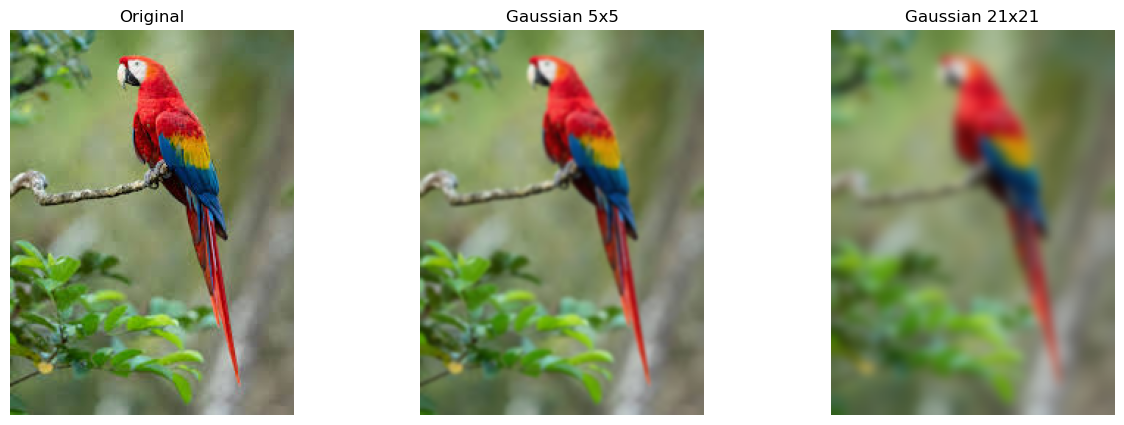

In [5]:
g5 = cv2.GaussianBlur(img, (5, 5), 0)
g21 = cv2.GaussianBlur(img, (21, 21), 0)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
for a, im, t in zip(ax, [img, g5, g21], ["Original", "Gaussian 5x5", "Gaussian 21x21"]):
    a.imshow(im); a.set_title(t); a.axis("off")
plt.show()

### Task 3: 3x3 Laplacian sharpening

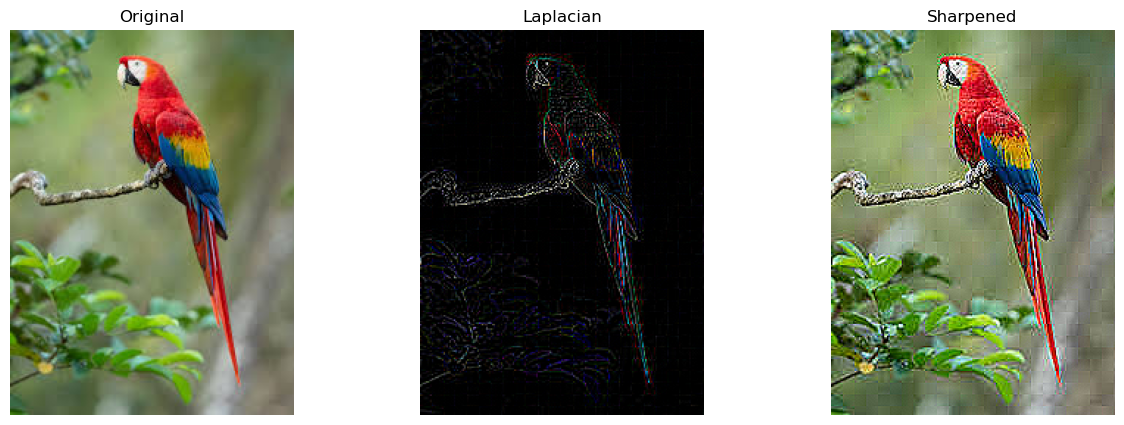

In [6]:
img_f = img.astype(np.float32) / 255.0
laplacian = cv2.Laplacian(img_f, cv2.CV_32F, ksize=1)  # ksize=1 -> 3x3 kernel
sharp = np.clip(img_f - laplacian, 0, 1)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(img); ax[0].set_title("Original"); ax[0].axis("off")
ax[1].imshow(np.clip(laplacian, 0, 1)); ax[1].set_title("Laplacian"); ax[1].axis("off")
ax[2].imshow(sharp); ax[2].set_title("Sharpened"); ax[2].axis("off")
plt.show()